In [3]:
import sys
from pathlib import Path

_root = next(p for p in Path.cwd().resolve().parents if (p / '.git').exists() or (p / 'setup.py').exists())
for _p in (str(_root), str(_root / 'src')):
    if _p not in sys.path:
        sys.path.insert(0, _p)

import numpy as np
import scanpy as sc
import gseapy as gp
from metab_processing.metab_travlr_config import DATA_DIR
from metab_processing.SpaceTravLR.dataset_configs import dataset_paths
from metab_processing.LinearRegression.build_x import add_gene_signature
from metab_processing.LinearRegression.least_squares import (
    fit_gene_betas, subsample_gene_betas, rank_coefficients,
    plot_top_coefficients, plot_beta_histogram)

dataset = 'Primary_Dermal_Melanoma'
data_dir = f'{DATA_DIR}/Xenium'
ANNOT_COL, CELL_TYPE = 'Tier1', 'T Cell'
METHOD, PENALTY, STANDARDIZE = 'l1', 0.05, True
N_SUB = 50
LOWER, UPPER = 15, 85
DBVER = '2024.1.Hs'

SIGNATURES = [
    # T cell biology
    'HALLMARK_IL2_STAT5_SIGNALING',
    'KEGG_T_CELL_RECEPTOR_SIGNALING_PATHWAY',
    'GOBP_T_CELL_MEDIATED_CYTOTOXICITY',
    'KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY',
    'HALLMARK_TNFA_SIGNALING_VIA_NFKB',
    'HALLMARK_INTERFERON_GAMMA_RESPONSE',
    # Metabolic
    'HALLMARK_OXIDATIVE_PHOSPHORYLATION',
    'HALLMARK_GLYCOLYSIS',
    'HALLMARK_HYPOXIA',
    'HALLMARK_FATTY_ACID_METABOLISM',
    'HALLMARK_MTORC1_SIGNALING',
    # Negative control
    'HALLMARK_PANCREAS_BETA_CELLS',
]

In [4]:
paths = dataset_paths(dataset, data_dir=data_dir)
adata = sc.read_h5ad(paths['dataset_dir'] / 'LinearRegression' / 'x_adata.h5ad')
var = set(adata.var_names)
print(adata.n_obs, 'cells |', len(adata.uns['x_genes']), 'built genes')

112551 cells | 697 built genes


In [5]:
# Fetch the gene sets, print each, and report which genes are absent from the data.
msig = gp.Msigdb()
library = {}
for cat in ('h.all', 'c2.cp.kegg_legacy', 'c5.go.bp'):
    try:
        library.update(msig.get_gmt(category=cat, dbver=DBVER) or {})
    except Exception as e:
        print(f'{cat}: FAILED ({e})')

sets = {}        # name -> genes PRESENT in adata (what each pseudo-gene is built from)
for name in SIGNATURES:
    genes = library.get(name)
    if genes is None:
        print(f'MISSING SET (name not found in MSigDB): {name}')
        continue
    present = [g for g in genes if g in var]
    absent = [g for g in genes if g not in var]
    sets[name] = present
    print(f'{name}: {len(present)}/{len(genes)} genes present'
          + (f'  | missing: {absent}' if absent else ''))

HALLMARK_IL2_STAT5_SIGNALING: 122/199 genes present  | missing: ['ADAM19', 'AHNAK', 'ANXA4', 'APLP1', 'ARL4A', 'BHLHE40', 'CA2', 'CAPG', 'CD48', 'CD81', 'CDC42SE2', 'CISH', 'COL6A1', 'CTSZ', 'CYFIP1', 'DCPS', 'DENND5A', 'DHRS3', 'ECM1', 'EEF1AKMT1', 'ENO3', 'ETFBKMT', 'ETV4', 'F2RL2', 'FAH', 'FGL2', 'GABARAPL1', 'GADD45B', 'GALM', 'GBP4', 'GPR65', 'GPX4', 'GUCY1B1', 'HYCC2', 'IFITM3', 'IL1R2', 'IRF6', 'KLF6', 'LCLAT1', 'LRIG1', 'LRRC8C', 'LTB', 'MAP3K8', 'MAP6', 'NFIL3', 'NFKBIZ', 'ODC1', 'PDCD2L', 'PHLDA1', 'PHTF2', 'PLPP1', 'PRAF2', 'PTRH2', 'PUS1', 'RABGAP1L', 'RGS16', 'RHOB', 'RNH1', 'RORA', 'RRAGD', 'SERPINB6', 'SHE', 'SLC29A2', 'SMPDL3A', 'SNX14', 'SNX9', 'SPP1', 'SPRED2', 'SPRY4', 'ST3GAL4', 'SWAP70', 'SYNGR2', 'SYT11', 'TNFRSF4', 'TTC39B', 'UCK2', 'WLS']
KEGG_T_CELL_RECEPTOR_SIGNALING_PATHWAY: 80/108 genes present  | missing: ['CBLC', 'CD3D', 'CHP1', 'CHP2', 'FOS', 'GRAP2', 'JUN', 'LCP2', 'MAP2K2', 'MAP2K7', 'MAP3K8', 'MAPK13', 'NCK2', 'NFKBIA', 'NFKBIB', 'NFKBIE', 'PAK3', 'PAK

In [6]:
for name in sets.keys():
    print(f'{name}: Present genes: {sets[name]}')

HALLMARK_IL2_STAT5_SIGNALING: Present genes: ['ABCB1', 'AGER', 'AHCY', 'AHR', 'ALCAM', 'AMACR', 'BATF', 'BATF3', 'BCL2', 'BCL2L1', 'BMP2', 'BMPR2', 'CAPN3', 'CASP3', 'CCND2', 'CCND3', 'CCNE1', 'CCR4', 'CD44', 'CD79B', 'CD83', 'CD86', 'CDC6', 'CDCP1', 'CDKN1C', 'CKAP4', 'COCH', 'CSF1', 'CSF2', 'CST7', 'CTLA4', 'CXCL10', 'DRC1', 'EMP1', 'ENPP1', 'EOMES', 'FLT3LG', 'FURIN', 'GATA1', 'GLIPR2', 'GPR83', 'GSTO1', 'HIPK2', 'HK2', 'HOPX', 'HUWE1', 'ICOS', 'IFNGR1', 'IGF1R', 'IGF2R', 'IKZF2', 'IKZF4', 'IL10', 'IL10RA', 'IL13', 'IL18R1', 'IL1RL1', 'IL2RA', 'IL2RB', 'IL3RA', 'IL4R', 'IRF4', 'IRF8', 'ITGA6', 'ITGAE', 'ITGAV', 'ITIH5', 'LIF', 'MAFF', 'MAPKAPK2', 'MUC1', 'MXD1', 'MYC', 'MYO1C', 'MYO1E', 'NCOA3', 'NCS1', 'NDRG1', 'NOP2', 'NRP1', 'NT5E', 'P2RX4', 'P4HA1', 'PENK', 'PIM1', 'PLAGL1', 'PLEC', 'PLIN2', 'PLSCR1', 'PNP', 'POU2F1', 'PRKCH', 'PRNP', 'PTCH1', 'PTGER2', 'PTH1R', 'RHOH', 'S100A1', 'SCN9A', 'SELL', 'SELP', 'SERPINC1', 'SH3BGRL2', 'SLC1A5', 'SLC2A3', 'SLC39A8', 'SOCS1', 'SOCS2', 'T

In [7]:
sets['HALLMARK_INTERFERON_GAMMA_RESPONSE'] = [x for x in sets['HALLMARK_INTERFERON_GAMMA_RESPONSE'] if x not in {'STAT1', 'IRF1', 'STAT2', 'STAT3', 'STAT4', 'IRF4', 'IRF7', 'NFKB1', 'FAS', 'IL15'}]

In [8]:
print(sets['HALLMARK_INTERFERON_GAMMA_RESPONSE'])

['ADAR', 'APOL6', 'BANK1', 'CASP1', 'CASP3', 'CASP7', 'CASP8', 'CCL7', 'CD274', 'CD38', 'CD40', 'CD86', 'CDKN1A', 'CFB', 'CFH', 'CIITA', 'CMKLR1', 'CSF2RB', 'CXCL10', 'CXCL11', 'CXCL9', 'EIF2AK2', 'FCGR1A', 'FPR1', 'GCH1', 'GZMA', 'HERC6', 'HIF1A', 'ICAM1', 'IDO1', 'IFI35', 'IFI44L', 'IFIH1', 'IFIT1', 'IFIT2', 'IFIT3', 'IFNAR2', 'IL10RA', 'IL15RA', 'IL18BP', 'IL2RB', 'IL4R', 'IL6', 'IL7', 'IRF5', 'IRF8', 'ITGB7', 'JAK2', 'KLRK1', 'LATS2', 'MVP', 'MX1', 'MYD88', 'NCOA3', 'NLRC5', 'NOD1', 'NUP93', 'OAS3', 'OGFR', 'P2RY14', 'PDE4B', 'PFKP', 'PIM1', 'PLA2G4A', 'PLSCR1', 'PML', 'PNP', 'PNPT1', 'PTGS2', 'PTPN1', 'PTPN2', 'PTPN6', 'RAPGEF6', 'RBCK1', 'RIPK1', 'RIPK2', 'RNF31', 'RSAD2', 'SAMHD1', 'SELP', 'SLAMF7', 'SOCS1', 'SOCS3', 'SP110', 'SPPL2A', 'SRI', 'TAP1', 'TDRD7', 'TNFSF10', 'TRAFD1', 'TRIM21', 'TRIM25', 'VAMP5', 'VCAM1', 'ZBP1']


In [9]:
def add_subsample_percentiles(betas_df, sub, lower=LOWER, upper=UPPER):
    """Add min/max and lower/upper-percentile subsample-beta columns to betas_df,
    matched by factor (`sub` = n_subsamples x factor DataFrame from subsample_gene_betas)."""
    out = betas_df.copy()
    def stat(fn):
        return [fn(sub[f]) if f in sub.columns else np.nan for f in out['factor']]
    out['min_subsample_beta'] = stat(np.nanmin)
    out['max_subsample_beta'] = stat(np.nanmax)
    out[f'lower_{lower}_subsample_beta'] = stat(lambda s: np.nanpercentile(s, lower))
    out[f'upper_{upper}_subsample_beta'] = stat(lambda s: np.nanpercentile(s, upper))
    return out

In [10]:
def run_signature(name, penalty=PENALTY, n_sub=N_SUB, lower=LOWER, upper=UPPER, top=15, keep_when_overlap='factor'):
    """All-positive pseudo-gene for `name` -> fit (L1/standardized) -> resample -> ranked
    betas with subsample-percentile columns. Prints a table + a top-coefficients plot.
    Returns (betas_with_percentiles, sub)."""
    if name not in sets:
        print(f'skip {name}: set not available'); return None, None
    genes = sets[name]
    ad2 = add_gene_signature(adata, name, positive=genes, keep_when_overlap=keep_when_overlap, verbose=True)   # negative=[] (all positive)
    b = fit_gene_betas(ad2, genes=[name], annot_col=ANNOT_COL, metabolites=[], annot_value=CELL_TYPE,
                       method=METHOD, penalty=penalty, standardize=STANDARDIZE)
    sub = subsample_gene_betas(ad2, name, factors=None, n_subsamples=n_sub,
                               annot_col=ANNOT_COL, annot_value=CELL_TYPE,
                               method=METHOD, penalty=penalty, standardize=STANDARDIZE)
    res = add_subsample_percentiles(rank_coefficients(b), sub, lower, upper)
    print(f'=== {name}: {len(genes)} genes present ===')
    display(res.head(60))
    if not res.empty:
        plot_top_coefficients(b, top=top).set_title(name)
    return res, sub

## T cell biology

[add_gene_signature 'HALLMARK_IL2_STAT5_SIGNALING'] factor_mode='union' keep_when_overlap='factor'
  dropped 51 gene(s) from the target: ['AHR', 'ALCAM', 'BATF', 'BATF3', 'BMP2', 'BMPR2', 'CCR4', 'CD44', 'CD86', 'CSF1', 'CSF2', 'CTLA4', 'CXCL10', 'EOMES', 'FLT3LG', 'GATA1', 'ICOS', 'IFNGR1', 'IGF1R', 'IGF2R', 'IKZF2', 'IKZF4', 'IL10', 'IL10RA', 'IL13', 'IL18R1', 'IL2RB', 'IL3RA', 'IL4R', 'IRF4', 'IRF8', 'ITGA6', 'ITGAE', 'ITGAV', 'LIF', 'MAFF', 'MYC', 'NRP1', 'PENK', 'PLAGL1', 'POU2F1', 'PTCH1', 'PTH1R', 'SELL', 'SELP', 'TNFRSF18', 'TNFRSF1B', 'TNFRSF9', 'TNFSF10', 'TNFSF11', 'XBP1']
  kept all 2531 factor(s)
=== HALLMARK_IL2_STAT5_SIGNALING: 122 genes present ===


,gene,factor,group,beta,r,r2,model_r2,n_cells,min_subsample_beta,max_subsample_beta,lower_15_subsample_beta,upper_85_subsample_beta
1468,HALLMARK_IL2_STAT5_SIGNALING,HMGA1,tf,0.174643,0.351680,0.123679,0.641097,9364,0.108814,0.197686,0.130645,0.175987
2075,HALLMARK_IL2_STAT5_SIGNALING,ATF4,tf,0.171549,0.362294,0.131257,0.641097,9364,0.094664,0.205870,0.126490,0.179588
1018,HALLMARK_IL2_STAT5_SIGNALING,TFAP2A,tf,0.155526,0.345627,0.119458,0.641097,9364,0.093032,0.187326,0.120105,0.162006
663,HALLMARK_IL2_STAT5_SIGNALING,L1CAM$L1CAM,lr,0.153332,0.327953,0.107553,0.641097,9364,0.058491,0.169032,0.096060,0.143436
1472,HALLMARK_IL2_STAT5_SIGNALING,MITF,tf,0.149870,0.288437,0.083196,0.641097,9364,0.074150,0.181785,0.109773,0.152255
610,HALLMARK_IL2_STAT5_SIGNALING,CD99$CD99,lr,0.143860,0.355929,0.126686,0.641097,9364,0.068628,0.162694,0.104016,0.141641
2168,HALLMARK_IL2_STAT5_SIGNALING,HOXB7,tf,0.136027,0.298881,0.089330,0.641097,9364,0.051700,0.183336,0.098443,0.146536
1983,HALLMARK_IL2_STAT5_SIGNALING,SOX10,tf,0.127247,0.345715,0.119519,0.641097,9364,0.058712,0.160913,0.080724,0.121237
2383,HALLMARK_IL2_STAT5_SIGNALING,EWSR1,tf,0.117789,0.304850,0.092933,0.641097,9364,0.061378,0.143891,0.090908,0.127196
55,HALLMARK_IL2_STAT5_SIGNALING,NFE2L2,tf,0.105641,0.251116,0.063059,0.641097,9364,0.050148,0.128833,0.068649,0.098622


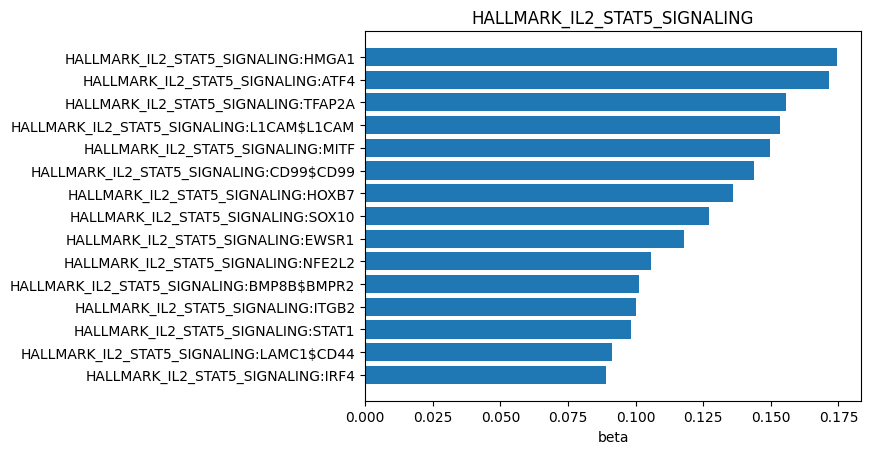

In [ ]:
res_il2, sub_il2 = run_signature('HALLMARK_IL2_STAT5_SIGNALING')

[add_gene_signature 'KEGG_T_CELL_RECEPTOR_SIGNALING_PATHWAY'] factor_mode='union' keep_when_overlap='factor'
  dropped 23 gene(s) from the target: ['CD28', 'CD4', 'CD40LG', 'CD8A', 'CD8B', 'CSF2', 'CTLA4', 'ICOS', 'IFNG', 'IL10', 'IL2', 'IL4', 'IL5', 'LCK', 'NFAT5', 'NFATC1', 'NFATC2', 'NFATC3', 'NFATC4', 'NFKB1', 'PDCD1', 'RELA', 'TNF']
  kept all 2474 factor(s)
=== KEGG_T_CELL_RECEPTOR_SIGNALING_PATHWAY: 80 genes present ===


,gene,factor,group,beta,r,r2,model_r2,n_cells,min_subsample_beta,max_subsample_beta,lower_15_subsample_beta,upper_85_subsample_beta
1947,KEGG_T_CELL_RECEPTOR_SIGNALING_PATHWAY,EWSR1,tf,0.237317,0.366279,0.134160,0.625116,9364,0.179179,0.277990,0.208035,0.255450
2385,KEGG_T_CELL_RECEPTOR_SIGNALING_PATHWAY,ITGB2,tf,0.195863,0.325981,0.106264,0.625116,9364,0.131882,0.234871,0.156559,0.199300
334,KEGG_T_CELL_RECEPTOR_SIGNALING_PATHWAY,IL7$IL2RG,lr,0.179167,0.298522,0.089115,0.625116,9364,0.112352,0.222430,0.134933,0.191915
1694,KEGG_T_CELL_RECEPTOR_SIGNALING_PATHWAY,IKZF1,tf,0.176080,0.266297,0.070914,0.625116,9364,0.117625,0.215181,0.141550,0.193677
2032,KEGG_T_CELL_RECEPTOR_SIGNALING_PATHWAY,ATF4,tf,0.169301,0.336840,0.113461,0.625116,9364,0.112872,0.191677,0.137423,0.183507
640,KEGG_T_CELL_RECEPTOR_SIGNALING_PATHWAY,CD99$CD99,lr,0.164342,0.329970,0.108880,0.625116,9364,0.098197,0.178191,0.123463,0.167902
1696,KEGG_T_CELL_RECEPTOR_SIGNALING_PATHWAY,IKZF3,tf,0.161879,0.214509,0.046014,0.625116,9364,0.119984,0.216434,0.145857,0.175754
93,KEGG_T_CELL_RECEPTOR_SIGNALING_PATHWAY,STAT1,tf,0.158199,0.351786,0.123754,0.625116,9364,0.092773,0.188936,0.122912,0.164307
2080,KEGG_T_CELL_RECEPTOR_SIGNALING_PATHWAY,CBFB,tf,0.142589,0.282269,0.079676,0.625116,9364,0.082683,0.183024,0.116066,0.161903
1828,KEGG_T_CELL_RECEPTOR_SIGNALING_PATHWAY,HOXB7,tf,0.123765,0.292107,0.085327,0.625116,9364,0.078957,0.167773,0.102682,0.149585


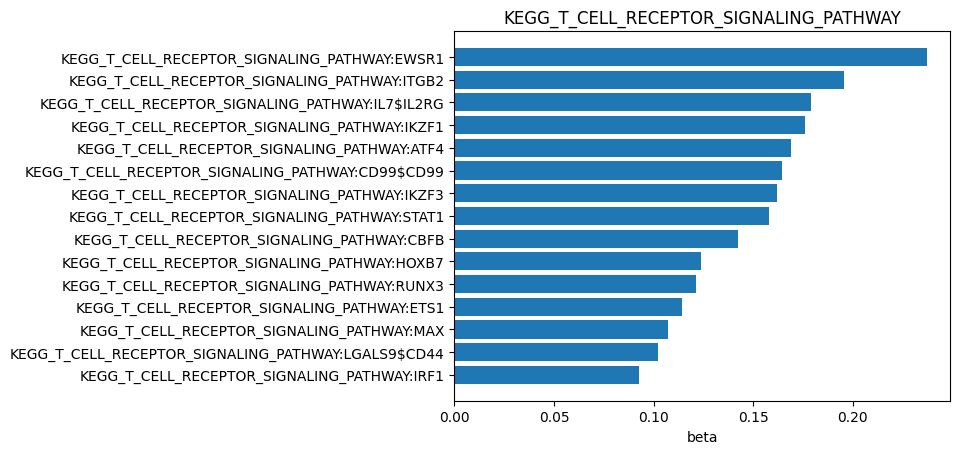

In [ ]:
res_tcr, sub_tcr = run_signature('KEGG_T_CELL_RECEPTOR_SIGNALING_PATHWAY')

[add_gene_signature 'GOBP_T_CELL_MEDIATED_CYTOTOXICITY'] factor_mode='union' keep_when_overlap='factor'
  dropped 7 gene(s) from the target: ['CEACAM1', 'IL12A', 'IL12B', 'IL12RB1', 'IL23A', 'NECTIN2', 'PVR']
  kept all 2344 factor(s)
=== GOBP_T_CELL_MEDIATED_CYTOTOXICITY: 36 genes present ===


,gene,factor,group,beta,r,r2,model_r2,n_cells,min_subsample_beta,max_subsample_beta,lower_15_subsample_beta,upper_85_subsample_beta
2026,GOBP_T_CELL_MEDIATED_CYTOTOXICITY,ITGB2,tf,0.115013,0.304474,0.092704,0.462166,9364,0.077270,0.135870,0.092071,0.115606
889,GOBP_T_CELL_MEDIATED_CYTOTOXICITY,STAT1,tf,0.103202,0.329067,0.108285,0.462166,9364,0.058944,0.110264,0.077325,0.103345
1732,GOBP_T_CELL_MEDIATED_CYTOTOXICITY,ATF4,tf,0.094348,0.304237,0.092560,0.462166,9364,0.043895,0.120921,0.071401,0.097839
579,GOBP_T_CELL_MEDIATED_CYTOTOXICITY,CD99$CD99,lr,0.086147,0.295388,0.087254,0.462166,9364,0.042214,0.106289,0.064646,0.084554
330,GOBP_T_CELL_MEDIATED_CYTOTOXICITY,IL16$CD4,lr,0.084962,0.242585,0.058848,0.462166,9364,0.039332,0.090584,0.052621,0.078851
1594,GOBP_T_CELL_MEDIATED_CYTOTOXICITY,EWSR1,tf,0.070380,0.291632,0.085049,0.462166,9364,0.034185,0.108331,0.050406,0.080238
277,GOBP_T_CELL_MEDIATED_CYTOTOXICITY,IL15$IL2RG,lr,0.061019,0.269784,0.072783,0.462166,9364,0.023259,0.094408,0.032293,0.064638
2160,GOBP_T_CELL_MEDIATED_CYTOTOXICITY,CBX5,tf,0.055679,0.227788,0.051887,0.462166,9364,0.012675,0.069639,0.031652,0.058490
861,GOBP_T_CELL_MEDIATED_CYTOTOXICITY,HOXB7,tf,0.052003,0.264114,0.069756,0.462166,9364,0.000000,0.089609,0.036535,0.066918
683,GOBP_T_CELL_MEDIATED_CYTOTOXICITY,SEMA4D$PLXNB2,lr,0.051534,0.205885,0.042389,0.462166,9364,0.010141,0.087217,0.029043,0.070164


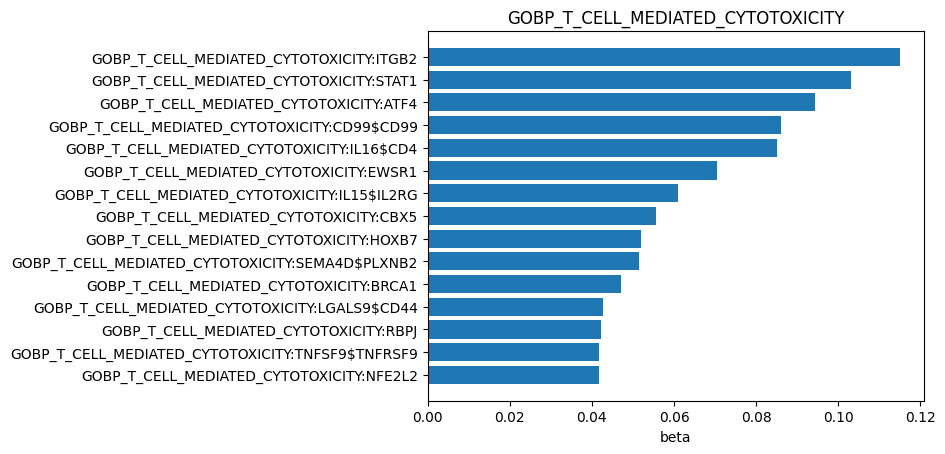

In [ ]:
res_tcyto, sub_tcyto = run_signature('GOBP_T_CELL_MEDIATED_CYTOTOXICITY')

[add_gene_signature 'KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY'] factor_mode='union' keep_when_overlap='factor'
  dropped 27 gene(s) from the target: ['CSF2', 'FAS', 'FASLG', 'ICAM1', 'ICAM2', 'IFNA1', 'IFNA17', 'IFNA2', 'IFNA7', 'IFNA8', 'IFNAR1', 'IFNAR2', 'IFNB1', 'IFNG', 'IFNGR1', 'IFNGR2', 'ITGAL', 'ITGB2', 'LCK', 'NFAT5', 'NFATC1', 'NFATC2', 'NFATC3', 'NFATC4', 'TNF', 'TNFRSF10A', 'TNFSF10']
  kept all 2464 factor(s)
=== KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY: 88 genes present ===


,gene,factor,group,beta,r,r2,model_r2,n_cells,min_subsample_beta,max_subsample_beta,lower_15_subsample_beta,upper_85_subsample_beta
2233,KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY,ITGB2,tf,0.204200,0.331089,0.109620,0.584201,9364,0.143989,0.242081,0.165164,0.216407
2400,KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY,EWSR1,tf,0.197411,0.350934,0.123155,0.584201,9364,0.155226,0.247488,0.174415,0.217250
2123,KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY,IKZF1,tf,0.169722,0.267161,0.071375,0.584201,9364,0.109486,0.219834,0.137608,0.190062
2125,KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY,IKZF3,tf,0.137129,0.209876,0.044048,0.584201,9364,0.098082,0.171087,0.116404,0.156859
1095,KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY,ATF4,tf,0.132306,0.314784,0.099089,0.584201,9364,0.068329,0.170302,0.095265,0.141572
1706,KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY,RUNX3,tf,0.130424,0.235883,0.055641,0.584201,9364,0.065773,0.185709,0.099838,0.155653
641,KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY,CD99$CD99,lr,0.129646,0.307051,0.094280,0.584201,9364,0.076540,0.175252,0.097839,0.134450
335,KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY,IL7$IL2RG,lr,0.118772,0.285803,0.081683,0.584201,9364,0.060239,0.169570,0.074504,0.137769
90,KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY,STAT1,tf,0.110477,0.327614,0.107331,0.584201,9364,0.047450,0.149858,0.079462,0.116909
1872,KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY,EOMES,tf,0.106936,0.178375,0.031818,0.584201,9364,0.049187,0.132656,0.089383,0.116916


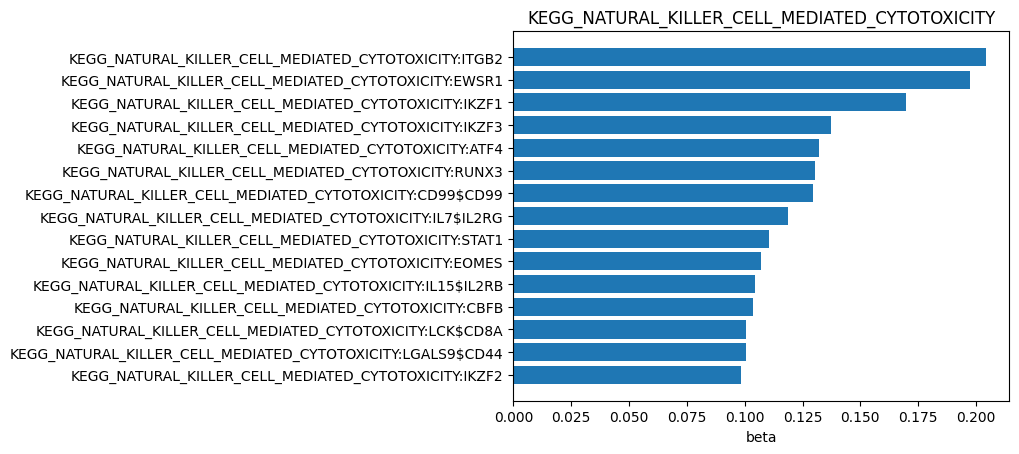

In [ ]:
res_nk, sub_nk = run_signature('KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY')

[add_gene_signature 'HALLMARK_TNFA_SIGNALING_VIA_NFKB'] factor_mode='union' keep_when_overlap='factor'
  dropped 58 gene(s) from the target: ['ACKR3', 'ATF3', 'BCL3', 'BCL6', 'BMP2', 'CCL20', 'CD44', 'CD80', 'CSF1', 'CSF2', 'CXCL10', 'CXCL11', 'CXCL2', 'CXCL6', 'EDN1', 'EGR2', 'EGR3', 'F2RL1', 'FOSL1', 'HBEGF', 'HES1', 'ICAM1', 'ICOSLG', 'IFNGR2', 'IL12B', 'IL15RA', 'IL18', 'IL1A', 'IL1B', 'IL23A', 'IL6', 'IL6ST', 'INHBA', 'IRF1', 'JAG1', 'KLF4', 'LAMB3', 'LIF', 'MAFF', 'MSC', 'MYC', 'NFAT5', 'NFE2L2', 'NFKB1', 'NFKB2', 'NR4A1', 'NR4A3', 'REL', 'RELA', 'RELB', 'SDC4', 'SMAD3', 'STAT5A', 'TNC', 'TNF', 'TNFRSF9', 'TNFSF9', 'VEGFA']
  kept all 2503 factor(s)
=== HALLMARK_TNFA_SIGNALING_VIA_NFKB: 109 genes present ===


,gene,factor,group,beta,r,r2,model_r2,n_cells,min_subsample_beta,max_subsample_beta,lower_15_subsample_beta,upper_85_subsample_beta
94,HALLMARK_TNFA_SIGNALING_VIA_NFKB,STAT1,tf,0.147920,0.352373,0.124167,0.512659,9364,0.077923,0.145759,0.095353,0.124835
1207,HALLMARK_TNFA_SIGNALING_VIA_NFKB,ATF4,tf,0.128430,0.318890,0.101691,0.512659,9364,0.083325,0.139786,0.094343,0.120801
640,HALLMARK_TNFA_SIGNALING_VIA_NFKB,CD99$CD99,lr,0.101582,0.303502,0.092114,0.512659,9364,0.031781,0.108786,0.061460,0.093540
42,HALLMARK_TNFA_SIGNALING_VIA_NFKB,IRF1,tf,0.092808,0.245160,0.060103,0.512659,9364,0.036964,0.099957,0.057469,0.083882
1630,HALLMARK_TNFA_SIGNALING_VIA_NFKB,HIF1A,tf,0.079745,0.193406,0.037406,0.512659,9364,0.032101,0.101700,0.047955,0.080250
391,HALLMARK_TNFA_SIGNALING_VIA_NFKB,IL16$CD4,lr,0.078608,0.230892,0.053311,0.512659,9364,0.000000,0.060974,0.020730,0.045783
672,HALLMARK_TNFA_SIGNALING_VIA_NFKB,ITGB2$ICAM1,lr,0.076787,0.232541,0.054076,0.512659,9364,0.007567,0.095473,0.035693,0.075540
514,HALLMARK_TNFA_SIGNALING_VIA_NFKB,LGALS9$CD44,lr,0.076403,0.302803,0.091690,0.512659,9364,0.000000,0.071182,0.019237,0.048991
1383,HALLMARK_TNFA_SIGNALING_VIA_NFKB,SOX10,tf,0.075652,0.273268,0.074675,0.512659,9364,0.027815,0.108421,0.045740,0.084597
2339,HALLMARK_TNFA_SIGNALING_VIA_NFKB,EWSR1,tf,0.073092,0.275628,0.075971,0.512659,9364,0.027752,0.092717,0.045337,0.073991


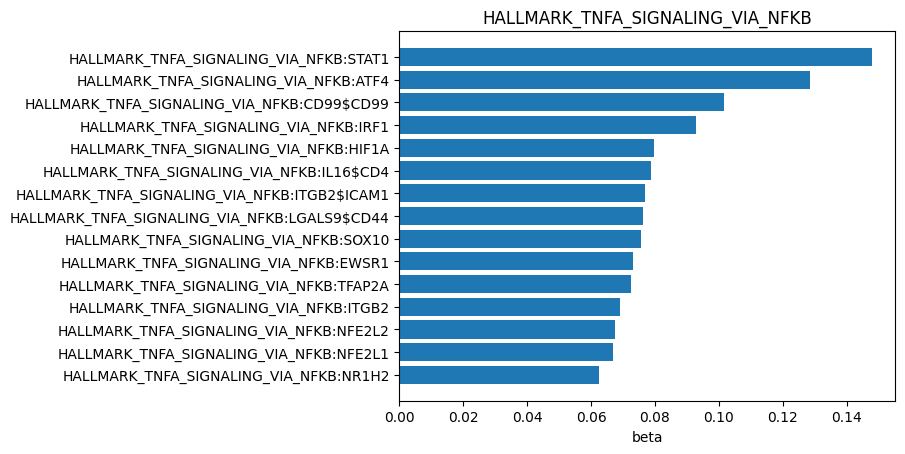

In [ ]:
res_tnfa, sub_tnfa = run_signature('HALLMARK_TNFA_SIGNALING_VIA_NFKB')

[add_gene_signature 'HALLMARK_INTERFERON_GAMMA_RESPONSE'] factor_mode='union' keep_when_overlap='factor'
  dropped 24 gene(s) from the target: ['CCL7', 'CD274', 'CD40', 'CD86', 'CSF2RB', 'CXCL10', 'CXCL11', 'CXCL9', 'GZMA', 'HIF1A', 'ICAM1', 'IFNAR2', 'IL10RA', 'IL15RA', 'IL2RB', 'IL4R', 'IL6', 'IL7', 'IRF5', 'IRF8', 'ITGB7', 'SELP', 'TNFSF10', 'VCAM1']
  kept all 2472 factor(s)
=== HALLMARK_INTERFERON_GAMMA_RESPONSE: 95 genes present ===


,gene,factor,group,beta,r,r2,model_r2,n_cells,min_subsample_beta,max_subsample_beta,lower_15_subsample_beta,upper_85_subsample_beta
139,HALLMARK_INTERFERON_GAMMA_RESPONSE,STAT1,tf,0.491198,0.431179,0.185915,0.613578,9364,0.341879,0.487093,0.395134,0.443354
2189,HALLMARK_INTERFERON_GAMMA_RESPONSE,EWSR1,tf,0.221979,0.349694,0.122286,0.613578,9364,0.135800,0.255188,0.177274,0.224308
64,HALLMARK_INTERFERON_GAMMA_RESPONSE,IRF1,tf,0.192163,0.282080,0.079569,0.613578,9364,0.124296,0.222541,0.145700,0.189024
1723,HALLMARK_INTERFERON_GAMMA_RESPONSE,ITGB2,tf,0.186097,0.330718,0.109375,0.613578,9364,0.115427,0.239215,0.140586,0.192381
2080,HALLMARK_INTERFERON_GAMMA_RESPONSE,HOXB7,tf,0.171246,0.288692,0.083343,0.613578,9364,0.082367,0.231529,0.141129,0.194867
566,HALLMARK_INTERFERON_GAMMA_RESPONSE,LGALS9$CD44,lr,0.166370,0.324667,0.105409,0.613578,9364,0.030026,0.165359,0.079378,0.134927
2223,HALLMARK_INTERFERON_GAMMA_RESPONSE,TNFSF13B#IKZF1,ltf,0.131628,0.292793,0.085728,0.613578,9364,0.000000,0.099039,0.000000,0.069077
692,HALLMARK_INTERFERON_GAMMA_RESPONSE,CD99$CD99,lr,0.128935,0.287768,0.082810,0.613578,9364,0.017499,0.152190,0.079284,0.117402
709,HALLMARK_INTERFERON_GAMMA_RESPONSE,GP1BA$ITGAM,lr,0.126547,0.079816,0.006371,0.613578,9364,0.000000,0.231056,0.000000,0.176478
390,HALLMARK_INTERFERON_GAMMA_RESPONSE,IL15$IL2RG,lr,0.121677,0.314623,0.098988,0.613578,9364,0.008903,0.165605,0.050668,0.123771


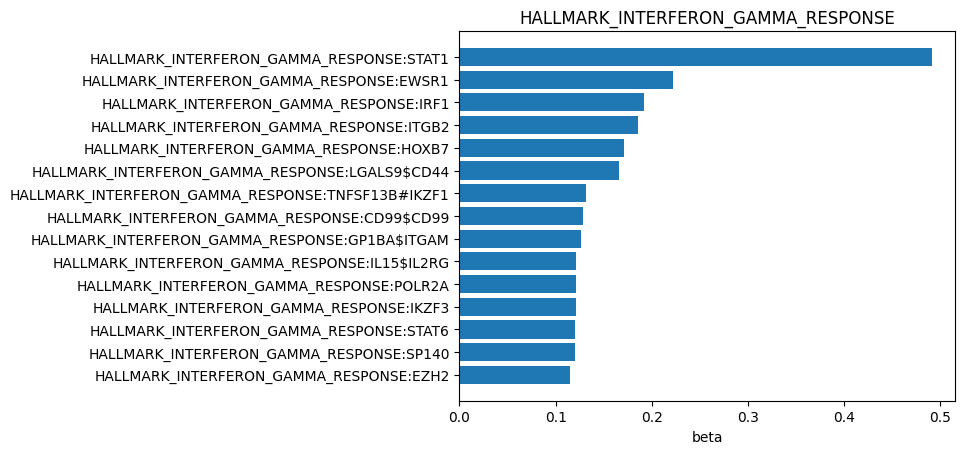

In [ ]:
res_ifng, sub_ifng = run_signature('HALLMARK_INTERFERON_GAMMA_RESPONSE')   # positive control

## Metabolic

[add_gene_signature 'HALLMARK_OXIDATIVE_PHOSPHORYLATION'] factor_mode='union' keep_when_overlap='factor'
  no overlap: kept 2399 factor(s), 45 target gene(s)
=== HALLMARK_OXIDATIVE_PHOSPHORYLATION: 45 genes present ===


,gene,factor,group,beta,r,r2,model_r2,n_cells,min_subsample_beta,max_subsample_beta,lower_15_subsample_beta,upper_85_subsample_beta
1119,HALLMARK_OXIDATIVE_PHOSPHORYLATION,HMGA1,tf,0.205015,0.360074,0.129653,0.656191,9364,0.131872,0.236422,0.144389,0.202991
1514,HALLMARK_OXIDATIVE_PHOSPHORYLATION,ATF4,tf,0.187920,0.367380,0.134968,0.656191,9364,0.118765,0.212260,0.146285,0.199178
1964,HALLMARK_OXIDATIVE_PHOSPHORYLATION,MYBL2,tf,0.182821,0.301017,0.090611,0.656191,9364,0.084994,0.223648,0.137188,0.194517
101,HALLMARK_OXIDATIVE_PHOSPHORYLATION,TFAP2A,tf,0.166753,0.318194,0.101247,0.656191,9364,0.097104,0.207973,0.116918,0.162200
2067,HALLMARK_OXIDATIVE_PHOSPHORYLATION,EWSR1,tf,0.164311,0.335760,0.112735,0.656191,9364,0.102750,0.187508,0.131646,0.176927
2240,HALLMARK_OXIDATIVE_PHOSPHORYLATION,SOX10,tf,0.145377,0.326997,0.106927,0.656191,9364,0.073576,0.166799,0.093688,0.140784
640,HALLMARK_OXIDATIVE_PHOSPHORYLATION,CD99$CD99,lr,0.143720,0.346924,0.120356,0.656191,9364,0.087803,0.176761,0.105914,0.154295
95,HALLMARK_OXIDATIVE_PHOSPHORYLATION,STAT1,tf,0.133272,0.348176,0.121226,0.656191,9364,0.077684,0.161203,0.090814,0.131677
1306,HALLMARK_OXIDATIVE_PHOSPHORYLATION,TRIM28,tf,0.132095,0.267327,0.071464,0.656191,9364,0.070923,0.176498,0.095798,0.144020
1258,HALLMARK_OXIDATIVE_PHOSPHORYLATION,BRCA1,tf,0.130437,0.244603,0.059830,0.656191,9364,0.059836,0.173985,0.090025,0.142357


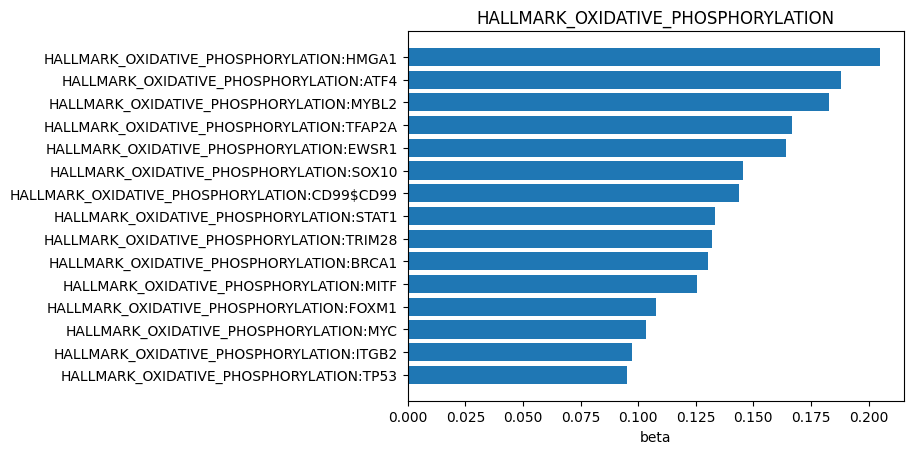

In [ ]:
res_oxphos, sub_oxphos = run_signature('HALLMARK_OXIDATIVE_PHOSPHORYLATION')

[add_gene_signature 'HALLMARK_GLYCOLYSIS'] factor_mode='union' keep_when_overlap='factor'
  dropped 13 gene(s) from the target: ['ADORA2B', 'ANGPTL4', 'CD44', 'CXCR4', 'EGFR', 'IL13RA1', 'MERTK', 'MET', 'SDC2', 'SDC3', 'SOX9', 'TGFA', 'VEGFA']
  kept all 2427 factor(s)
=== HALLMARK_GLYCOLYSIS: 74 genes present ===


,gene,factor,group,beta,r,r2,model_r2,n_cells,min_subsample_beta,max_subsample_beta,lower_15_subsample_beta,upper_85_subsample_beta
594,HALLMARK_GLYCOLYSIS,CD99$CD99,lr,0.212759,0.370725,0.137437,0.674471,9364,0.158323,0.249092,0.176443,0.209344
1672,HALLMARK_GLYCOLYSIS,ATF4,tf,0.205457,0.373829,0.139748,0.674471,9364,0.148461,0.231350,0.175711,0.210262
1731,HALLMARK_GLYCOLYSIS,FOXM1,tf,0.202883,0.325483,0.105939,0.674471,9364,0.131651,0.258431,0.163719,0.210918
1616,HALLMARK_GLYCOLYSIS,MYBL2,tf,0.201424,0.316277,0.100031,0.674471,9364,0.116405,0.236541,0.176552,0.225239
1502,HALLMARK_GLYCOLYSIS,EWSR1,tf,0.183101,0.348433,0.121406,0.674471,9364,0.142151,0.218003,0.158642,0.194175
1930,HALLMARK_GLYCOLYSIS,SOX10,tf,0.149087,0.323311,0.104530,0.674471,9364,0.070667,0.174772,0.092702,0.144907
1503,HALLMARK_GLYCOLYSIS,EZH2,tf,0.135104,0.295939,0.087580,0.674471,9364,0.063664,0.192758,0.101485,0.154911
2277,HALLMARK_GLYCOLYSIS,HOXB7,tf,0.128944,0.315521,0.099553,0.674471,9364,0.099627,0.194358,0.120744,0.160060
24,HALLMARK_GLYCOLYSIS,MITF,tf,0.126394,0.255704,0.065384,0.674471,9364,0.045763,0.144747,0.085849,0.132267
1323,HALLMARK_GLYCOLYSIS,TRIM28,tf,0.125557,0.265994,0.070753,0.674471,9364,0.057131,0.171283,0.097726,0.137332


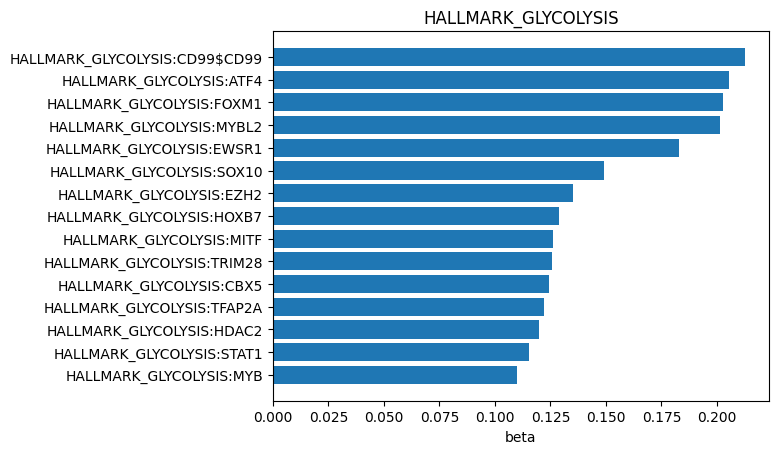

In [ ]:
res_glyc, sub_glyc = run_signature('HALLMARK_GLYCOLYSIS')

[add_gene_signature 'HALLMARK_HYPOXIA'] factor_mode='union' keep_when_overlap='factor'
  dropped 23 gene(s) from the target: ['ACKR3', 'ADM', 'ADORA2B', 'ANGPTL4', 'ATF3', 'CXCR4', 'DDIT3', 'EGFR', 'ETS1', 'FOXO3', 'HOXB9', 'IL6', 'INHA', 'MAFF', 'NR3C1', 'PDGFB', 'PPARGC1A', 'RBPJ', 'SDC2', 'SDC3', 'SDC4', 'TGFB3', 'VEGFA']
  kept all 2458 factor(s)
=== HALLMARK_HYPOXIA: 96 genes present ===


,gene,factor,group,beta,r,r2,model_r2,n_cells,min_subsample_beta,max_subsample_beta,lower_15_subsample_beta,upper_85_subsample_beta
575,HALLMARK_HYPOXIA,CD99$CD99,lr,0.178194,0.346065,0.119761,0.612081,9364,0.124770,0.196481,0.136999,0.183921
832,HALLMARK_HYPOXIA,ATF4,tf,0.172517,0.352293,0.124110,0.612081,9364,0.091993,0.196235,0.138508,0.175615
1438,HALLMARK_HYPOXIA,EWSR1,tf,0.158719,0.332196,0.110354,0.612081,9364,0.109113,0.208332,0.134011,0.179725
2031,HALLMARK_HYPOXIA,HOXB7,tf,0.125127,0.300240,0.090144,0.612081,9364,0.079046,0.172697,0.107359,0.141826
1962,HALLMARK_HYPOXIA,ITGB2,tf,0.123645,0.288716,0.083357,0.612081,9364,0.050081,0.130830,0.077687,0.114427
1940,HALLMARK_HYPOXIA,SOX10,tf,0.113443,0.286344,0.081993,0.612081,9364,0.042447,0.171898,0.065311,0.109577
872,HALLMARK_HYPOXIA,STAT1,tf,0.110438,0.340169,0.115715,0.612081,9364,0.059552,0.138871,0.081908,0.116607
1748,HALLMARK_HYPOXIA,FOXM1,tf,0.105391,0.261581,0.068425,0.612081,9364,0.062478,0.141030,0.081896,0.120846
2023,HALLMARK_HYPOXIA,CBX5,tf,0.095140,0.254054,0.064544,0.612081,9364,0.047505,0.125754,0.064689,0.101036
1570,HALLMARK_HYPOXIA,MYBL2,tf,0.084481,0.245120,0.060084,0.612081,9364,0.030387,0.130765,0.053357,0.099338


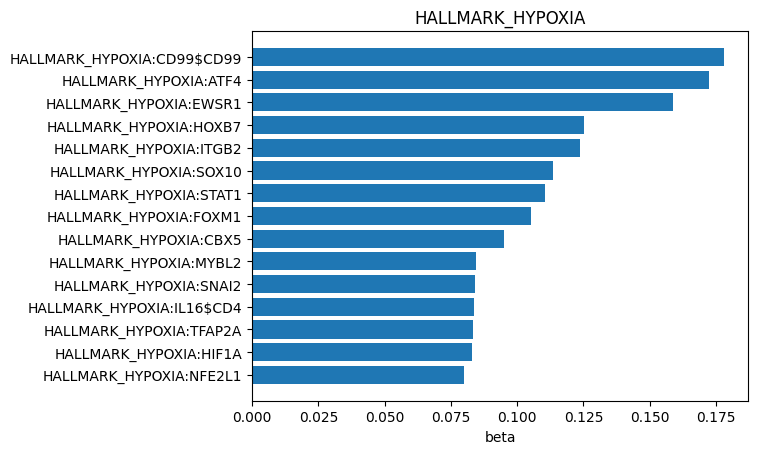

In [ ]:
res_hyp, sub_hyp = run_signature('HALLMARK_HYPOXIA')

[add_gene_signature 'HALLMARK_FATTY_ACID_METABOLISM'] factor_mode='union' keep_when_overlap='factor'
  dropped 4 gene(s) from the target: ['ADIPOR2', 'BMPR1B', 'CD36', 'PPARA']
  kept all 2394 factor(s)
=== HALLMARK_FATTY_ACID_METABOLISM: 47 genes present ===


,gene,factor,group,beta,r,r2,model_r2,n_cells,min_subsample_beta,max_subsample_beta,lower_15_subsample_beta,upper_85_subsample_beta
1836,HALLMARK_FATTY_ACID_METABOLISM,SOX10,tf,0.136799,0.327008,0.106934,0.53706,9364,0.083782,0.158011,0.095722,0.132736
2240,HALLMARK_FATTY_ACID_METABOLISM,ATF4,tf,0.118263,0.336205,0.113033,0.53706,9364,0.063653,0.144350,0.089335,0.120980
101,HALLMARK_FATTY_ACID_METABOLISM,TFAP2A,tf,0.108881,0.305445,0.093297,0.53706,9364,0.066088,0.126411,0.088372,0.116808
2008,HALLMARK_FATTY_ACID_METABOLISM,HMGA1,tf,0.106728,0.325115,0.105700,0.53706,9364,0.041086,0.122813,0.075128,0.108271
1115,HALLMARK_FATTY_ACID_METABOLISM,MYBL2,tf,0.104930,0.268020,0.071835,0.53706,9364,0.056296,0.135757,0.079888,0.116361
640,HALLMARK_FATTY_ACID_METABOLISM,CD99$CD99,lr,0.096001,0.322609,0.104077,0.53706,9364,0.058866,0.110325,0.070307,0.094150
95,HALLMARK_FATTY_ACID_METABOLISM,STAT1,tf,0.087817,0.323533,0.104674,0.53706,9364,0.049629,0.115891,0.063813,0.095193
2184,HALLMARK_FATTY_ACID_METABOLISM,EWSR1,tf,0.072252,0.290132,0.084176,0.53706,9364,0.027553,0.096673,0.056733,0.081312
1515,HALLMARK_FATTY_ACID_METABOLISM,TRIM28,tf,0.072211,0.240747,0.057959,0.53706,9364,0.034060,0.116036,0.046399,0.081476
1211,HALLMARK_FATTY_ACID_METABOLISM,HOXB7,tf,0.068427,0.295140,0.087107,0.53706,9364,0.050392,0.096088,0.063438,0.087975


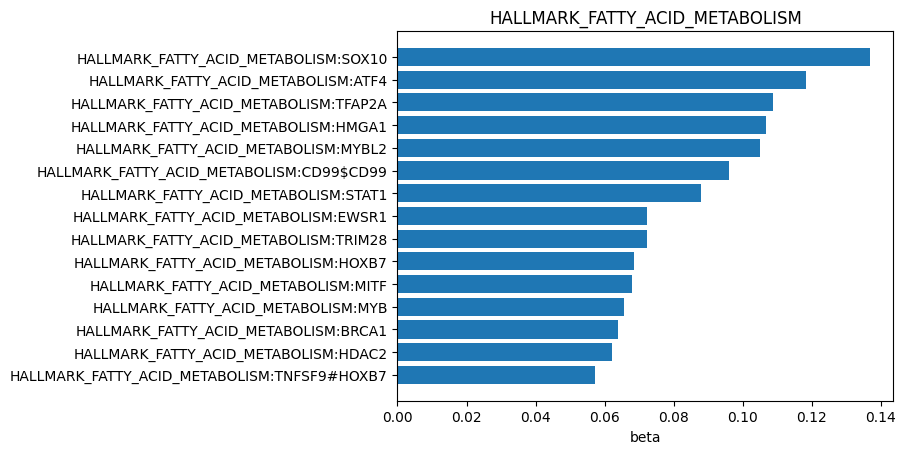

In [ ]:
res_fao, sub_fao = run_signature('HALLMARK_FATTY_ACID_METABOLISM')

[add_gene_signature 'HALLMARK_MTORC1_SIGNALING'] factor_mode='union' keep_when_overlap='factor'
  dropped 5 gene(s) from the target: ['ADIPOR2', 'CXCR4', 'DDIT3', 'ITGB2', 'XBP1']
  kept all 2468 factor(s)
=== HALLMARK_MTORC1_SIGNALING: 91 genes present ===


,gene,factor,group,beta,r,r2,model_r2,n_cells,min_subsample_beta,max_subsample_beta,lower_15_subsample_beta,upper_85_subsample_beta
59,HALLMARK_MTORC1_SIGNALING,MYBL2,tf,0.433432,0.354464,0.125645,0.751545,9364,0.303826,0.510189,0.355248,0.446098
1832,HALLMARK_MTORC1_SIGNALING,HMGA1,tf,0.305382,0.378125,0.142979,0.751545,9364,0.175221,0.319662,0.223643,0.287905
2043,HALLMARK_MTORC1_SIGNALING,FOXM1,tf,0.286901,0.330321,0.109112,0.751545,9364,0.192105,0.359145,0.233080,0.317346
1607,HALLMARK_MTORC1_SIGNALING,ATF4,tf,0.258972,0.376742,0.141934,0.751545,9364,0.153462,0.293370,0.202069,0.258102
656,HALLMARK_MTORC1_SIGNALING,CD99$CD99,lr,0.253443,0.364936,0.133178,0.751545,9364,0.143826,0.303203,0.188291,0.236908
2373,HALLMARK_MTORC1_SIGNALING,ITGB2,tf,0.251135,0.299585,0.089751,0.751545,9364,0.139397,0.251463,0.167101,0.231879
2009,HALLMARK_MTORC1_SIGNALING,EWSR1,tf,0.238916,0.358069,0.128213,0.751545,9364,0.173292,0.274977,0.205036,0.243263
1323,HALLMARK_MTORC1_SIGNALING,HOXB7,tf,0.235416,0.325645,0.106045,0.751545,9364,0.136273,0.302448,0.186895,0.270277
116,HALLMARK_MTORC1_SIGNALING,TRIM28,tf,0.226627,0.288760,0.083382,0.751545,9364,0.129530,0.269133,0.162542,0.243549
1608,HALLMARK_MTORC1_SIGNALING,BRCA1,tf,0.214407,0.258007,0.066568,0.751545,9364,0.102725,0.292074,0.153257,0.237938


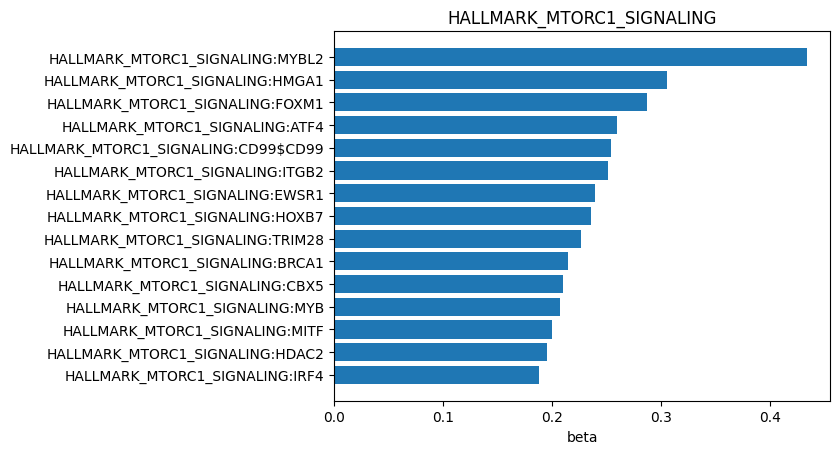

In [ ]:
res_mtor, sub_mtor = run_signature('HALLMARK_MTORC1_SIGNALING')

## Negative control

[add_gene_signature 'HALLMARK_PANCREAS_BETA_CELLS'] factor_mode='union' keep_when_overlap='factor'
  dropped 10 gene(s) from the target: ['FOXA2', 'FOXO1', 'INSM1', 'ISL1', 'LMO2', 'MAFB', 'NEUROD1', 'PAX6', 'PDX1', 'VDR']
  kept all 2173 factor(s)


=== HALLMARK_PANCREAS_BETA_CELLS: 18 genes present ===


,gene,factor,group,beta,r,r2,model_r2,n_cells,min_subsample_beta,max_subsample_beta,lower_15_subsample_beta,upper_85_subsample_beta
2172,HALLMARK_PANCREAS_BETA_CELLS,IL21#ERG,ltf,0.0,-0.007478,5.592313e-05,-2.220446e-16,9364,0.0,0.0,0.0,0.0
0,HALLMARK_PANCREAS_BETA_CELLS,AHR,tf,0.0,0.039864,1.589107e-03,-2.220446e-16,9364,0.0,0.0,0.0,0.0
1,HALLMARK_PANCREAS_BETA_CELLS,ARNT,tf,0.0,0.038328,1.469054e-03,-2.220446e-16,9364,0.0,0.0,0.0,0.0
2,HALLMARK_PANCREAS_BETA_CELLS,ATF3,tf,0.0,0.033487,1.121387e-03,-2.220446e-16,9364,0.0,0.0,0.0,0.0
3,HALLMARK_PANCREAS_BETA_CELLS,BCL3,tf,0.0,0.014349,2.059004e-04,-2.220446e-16,9364,0.0,0.0,0.0,0.0
4,HALLMARK_PANCREAS_BETA_CELLS,CLOCK,tf,0.0,0.057697,3.328971e-03,-2.220446e-16,9364,0.0,0.0,0.0,0.0
5,HALLMARK_PANCREAS_BETA_CELLS,E2F1,tf,0.0,0.043552,1.896764e-03,-2.220446e-16,9364,0.0,0.0,0.0,0.0
6,HALLMARK_PANCREAS_BETA_CELLS,E2F3,tf,0.0,0.038529,1.484478e-03,-2.220446e-16,9364,0.0,0.0,0.0,0.0
7,HALLMARK_PANCREAS_BETA_CELLS,E2F4,tf,0.0,0.023374,5.463328e-04,-2.220446e-16,9364,0.0,0.0,0.0,0.0
8,HALLMARK_PANCREAS_BETA_CELLS,EGR2,tf,0.0,0.024170,5.841910e-04,-2.220446e-16,9364,0.0,0.0,0.0,0.0


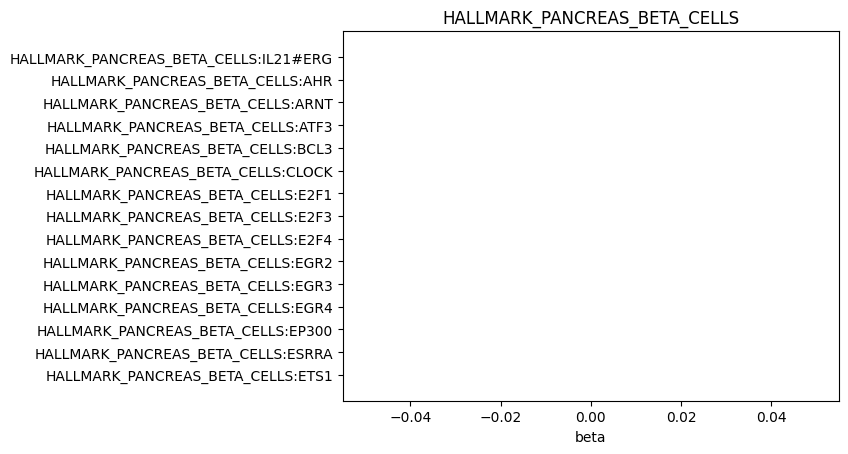

In [ ]:
res_neg, sub_neg = run_signature('HALLMARK_PANCREAS_BETA_CELLS')

## Distribution of a single factor (edit the signature / factor)

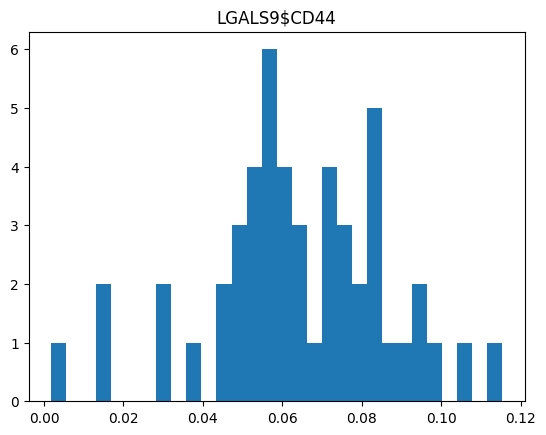

In [ ]:
sub = sub_il2                 # <- any signature's resample output from above
FACTOR = 'LGALS9$CD44' # <- any factor name (tf / lig$rec / lig#tf / metab@name)
plot_beta_histogram(sub[FACTOR], title=FACTOR);

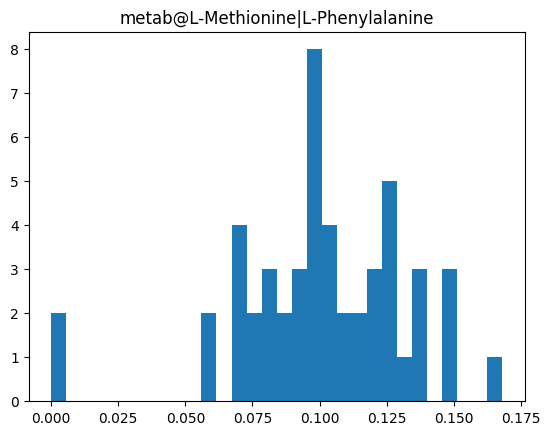

In [ ]:
sub = sub_il2                 # <- any signature's resample output from above
FACTOR = 'metab@L-Methionine|L-Phenylalanine' # <- any factor name (tf / lig$rec / lig#tf / metab@name)
plot_beta_histogram(sub[FACTOR], title=FACTOR);

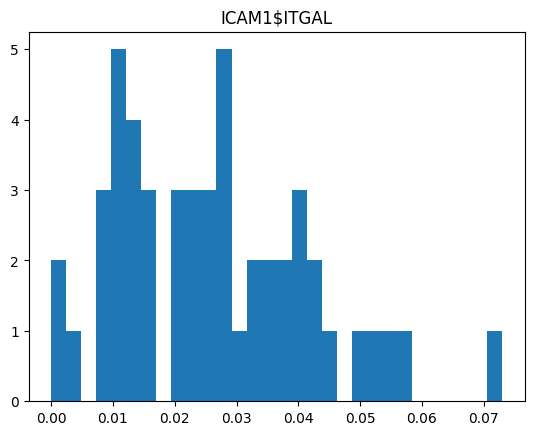

In [ ]:
sub = sub_il2                 # <- any signature's resample output from above
FACTOR = 'ICAM1$ITGAL' # <- any factor name (tf / lig$rec / lig#tf / metab@name)
plot_beta_histogram(sub[FACTOR], title=FACTOR);